In [1]:
#========================================================================
# Name: filter_wrf_dsd_properties_congestus.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
# Date Created: 05/22/2025
#
# Utility: Reads in CTH variables from derived files and pulls in the
# corresponding derived gamma dsd properties. Then limits the simulated
# dataset to the ridgeline, CTTs at least shallow enough to be considered
# congestus (i.e., > -25 deg C), and limits points in general to be above 0
# deg C.
#========================================================================

In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob 
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.colors as colors
import matplotlib as mpl
from pytz import utc
from matplotlib.lines import Line2D
import pickle
from scipy.spatial import cKDTree
import pandas as pd

import dask
from distributed import Client, LocalCluster
from dask import delayed, compute
import dask.array as da

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import matplotlib.patheffects as path_effects

import scipy
import warnings
warnings.filterwarnings("ignore")
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

plt.rcParams['text.usetex'] = True

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


# Dask stuff

In [2]:
dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

In [3]:
cluster = LocalCluster(n_workers=80,threads_per_worker=1,memory_limit='5GB')#,dashboard_address=':8787')
client = Client(cluster)

In [4]:
cluster

LocalCluster(74db47b4, 'tcp://127.0.0.1:41005', workers=80, threads=80, memory=372.53 GiB)

In [5]:
def suppress_warnings():
    import warnings
    warnings.filterwarnings("ignore", message=".*All-NaN axis encountered*", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

client.run(suppress_warnings)

{'tcp://127.0.0.1:32817': None,
 'tcp://127.0.0.1:32879': None,
 'tcp://127.0.0.1:32927': None,
 'tcp://127.0.0.1:33213': None,
 'tcp://127.0.0.1:33853': None,
 'tcp://127.0.0.1:34079': None,
 'tcp://127.0.0.1:34191': None,
 'tcp://127.0.0.1:34555': None,
 'tcp://127.0.0.1:34577': None,
 'tcp://127.0.0.1:34583': None,
 'tcp://127.0.0.1:34781': None,
 'tcp://127.0.0.1:34959': None,
 'tcp://127.0.0.1:35027': None,
 'tcp://127.0.0.1:35287': None,
 'tcp://127.0.0.1:35321': None,
 'tcp://127.0.0.1:35383': None,
 'tcp://127.0.0.1:35617': None,
 'tcp://127.0.0.1:35653': None,
 'tcp://127.0.0.1:36063': None,
 'tcp://127.0.0.1:36225': None,
 'tcp://127.0.0.1:36311': None,
 'tcp://127.0.0.1:36487': None,
 'tcp://127.0.0.1:36495': None,
 'tcp://127.0.0.1:36859': None,
 'tcp://127.0.0.1:37075': None,
 'tcp://127.0.0.1:37089': None,
 'tcp://127.0.0.1:37185': None,
 'tcp://127.0.0.1:37225': None,
 'tcp://127.0.0.1:37367': None,
 'tcp://127.0.0.1:37507': None,
 'tcp://127.0.0.1:37791': None,
 'tcp://

In [12]:
%%time
print('Step 1')
# Step 1: List .npz files
npz_files = sorted(glob.glob('/pscratch/sd/m/mckenna/cacti/wrf/temp_cong_dsd_params/LASSO_d2_cong_dsd_params_*.npz'))
print('Step 2')
# Step 2: Get all keys by inspecting the first file
with np.load(npz_files[0]) as sample:
    all_keys = list(sample.keys())
print('Step 3')
# Step 3: Delayed function to load a single file
@delayed
def load_npz_var(filepath, varname):
    with np.load(filepath) as data:
        return data[varname]
print('Step 4')
# Step 4: For each variable, collect delayed arrays and concatenate
def extract_and_concat(varname, file_list):
    delayed_arrays = [load_npz_var(f, varname) for f in file_list]
    return delayed(np.concatenate)(delayed_arrays)
print('Step 5')
# Step 5: Build delayed concatenation for each variable
concatenated_vars = {
    k: extract_and_concat(k, npz_files) for k in all_keys
}
print('Step 6')
# Step 6: Compute in parallel
computed_values = compute(*concatenated_vars.values())
print('Step 7')

# Step 7: Reconstruct dictionary
wrf_dict = dict(zip(concatenated_vars.keys(), computed_values))

Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
CPU times: user 9.48 s, sys: 2.16 s, total: 11.6 s
Wall time: 11.6 s


In [13]:
#for key,val in wrf_dict.items():
#    print(key,np.shape(val),np.nanmax(val),np.nanmin(val))

In [14]:
with open('LASSO_d2_dsd_props_cu_only.p', 'wb') as f:
    pickle.dump(wrf_dict, f)

# Experiment with RH thresholds

In [3]:
if False:
    filter_rh_bool = False
    rh_thresh_native = 99.
    rh_thresh_cg = 95.
    #var = 'RH'
    var = 'RH_native'
    
    #===============================
    # 3-km
    #===============================
    rh_thresh = rh_thresh_native
    domain = '3km'
    print(f'Domain: {domain}')
    
    with open('wrf_dsd_props_cu_only.p', 'rb') as f:
        wrf_dict = pickle.load(f)
    wrf_dict['N'] = wrf_dict['N']*wrf_dict['rho_air']*1.e-6
    
    cloud_id = np.where(wrf_dict['RH'] >= rh_thresh)[0]
    non_cloud_id = np.where(wrf_dict['RH'] < rh_thresh)[0]
    print(f'# of points with RH >= {rh_thresh}%:',len(cloud_id))
    print(f'% of points with RH >= {rh_thresh}%:',len(cloud_id)/len(wrf_dict['RH'])*100.)
    print(f'% of points with RH < {rh_thresh}%:',len(non_cloud_id)/len(wrf_dict['RH'])*100.)
    
    if filter_rh_bool:
        for key,val in wrf_dict.items():
            wrf_dict[key] = val[cloud_id]
    
    #===============================
    # 2.5-km
    #===============================
    rh_thresh = rh_thresh_native
    domain = 'd2'
    print(f'Domain: {domain}')
    with open('LASSO_d2_dsd_props_cu_only.p', 'rb') as f:
        d2_wrf_dict = pickle.load(f)
    d2_wrf_dict['N'] = d2_wrf_dict['N']*d2_wrf_dict['rho_air']*1.e-6
    
    d2_cloud_id = np.where(d2_wrf_dict[var] >= rh_thresh)[0]
    d2_non_cloud_id = np.where(d2_wrf_dict[var] < rh_thresh)[0]
    print(f'# of points with RH >= {rh_thresh}%:',len(d2_cloud_id))
    print(f'% of points with RH >= {rh_thresh}%:',len(d2_cloud_id)/len(d2_wrf_dict[var])*100.)
    print(f'% of points with RH < {rh_thresh}%:',len(d2_non_cloud_id)/len(d2_wrf_dict[var])*100.)
    
    if filter_rh_bool:
        for key,val in d2_wrf_dict.items():
            d2_wrf_dict[key] = val[d2_cloud_id]
    
    #===============================
    # 500-m
    #===============================
    
    rh_thresh = rh_thresh_native
    domain = 'd3_native'
    print(f'Domain: {domain}')
    
    with open('LASSO_500m_native_dsd_props_cu_only.p', 'rb') as f:
        d3_native_wrf_dict = pickle.load(f)
    d3_native_wrf_dict['N'] = d3_native_wrf_dict['N']*d3_native_wrf_dict['rho_air']*1.e-6
    
    d3_native_cloud_id = np.where(d3_native_wrf_dict[var] >= rh_thresh)[0]
    d3_native_non_cloud_id = np.where(d3_native_wrf_dict[var] < rh_thresh)[0]
    print(f'# of points with RH >= {rh_thresh}%:',len(d3_native_cloud_id))
    print(f'% of points with RH >= {rh_thresh}%:',len(d3_native_cloud_id)/len(d3_native_wrf_dict[var])*100.)
    print(f'% of points with RH < {rh_thresh}%:',len(d3_native_non_cloud_id)/len(d3_native_wrf_dict[var])*100.)
    
    if filter_rh_bool:
        for key,val in d3_native_wrf_dict.items():
            d3_native_wrf_dict[key] = val[d3_native_cloud_id]
    
    
    #===============================
    # 500-m coarse-grained
    #===============================
    rh_thresh = rh_thresh_cg
    domain = 'd3'
    print(f'Domain: {domain}')
    
    with open('LASSO_d3_dsd_props_cu_only.p', 'rb') as f:
        d3_wrf_dict = pickle.load(f)
    d3_wrf_dict['N'] = d3_wrf_dict['N']*d3_wrf_dict['rho_air']*1.e-6
    
    d3_cloud_id = np.where(d3_wrf_dict[var] >= rh_thresh)[0]
    d3_non_cloud_id = np.where(d3_wrf_dict[var] < rh_thresh)[0]
    print(f'# of points with RH >= {rh_thresh}%:',len(d3_cloud_id))
    print(f'% of points with RH >= {rh_thresh}%:',len(d3_cloud_id)/len(d3_wrf_dict[var])*100.)
    print(f'% of points with RH < {rh_thresh}%:',len(d3_non_cloud_id)/len(d3_wrf_dict[var])*100.)
    
    if filter_rh_bool:
        for key,val in d3_wrf_dict.items():
            d3_wrf_dict[key] = val[d3_cloud_id]
    
    
    #===============================
    # 100-m coarse-grained
    #===============================
    rh_thresh = rh_thresh_cg
    domain = 'd4'
    print(f'Domain: {domain}')
    
    with open('LASSO_d4_dsd_props_cu_only.p', 'rb') as f:
        d4_wrf_dict = pickle.load(f)
    d4_wrf_dict['N'] = d4_wrf_dict['N']*d4_wrf_dict['rho_air']*1.e-6
    
    d4_cloud_id = np.where(d4_wrf_dict[var] >= rh_thresh)[0]
    d4_non_cloud_id = np.where(d4_wrf_dict[var] < rh_thresh)[0]
    print(f'# of points with RH >= {rh_thresh}%:',len(d4_cloud_id))
    print(f'% of points with RH >= {rh_thresh}%:',len(d4_cloud_id)/len(d4_wrf_dict[var])*100.)
    print(f'% of points with RH < {rh_thresh}%:',len(d4_non_cloud_id)/len(d4_wrf_dict[var])*100.)
    
    if filter_rh_bool:
        for key,val in d4_wrf_dict.items():
            d4_wrf_dict[key] = val[d4_cloud_id]


    fig = plt.figure(figsize=(18,8),constrained_layout=True)
    ax1 = fig.add_subplot(231)
    ax2 = fig.add_subplot(232)
    ax3 = fig.add_subplot(233)
    ax4 = fig.add_subplot(235)
    ax5 = fig.add_subplot(236)
    axlist = [ax1,ax2,ax3,ax4,ax5]
    Fontsize=14
    for ax in axlist:
        ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
        ax.tick_params(labelsize=Fontsize)
        ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
        ax.set_ylabel('RH [\%]',fontsize=Fontsize)
        ax.set_xscale('log')
    
    rh_bins = np.arange(0,110,5)
    lwc_bins = 10.**np.arange(-3,1.2,0.2)
    
    #==========================
    # 3 km 
    #==========================
    ax1.set_title(r'\textbf{3 km (Native)}',fontsize=Fontsize*1.5)
    tmpplot=ax1.hist2d(wrf_dict['lwc'],wrf_dict['RH'],bins=(lwc_bins,rh_bins),cmap='inferno')#,norm=mpl.colors.LogNorm())
    cbar=plt.colorbar(tmpplot[3])
    cbar.ax.set_ylabel('Count',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    #==========================
    # 2.5 km 
    #==========================
    ax2.set_title(r'\textbf{2.5 km (Native)}',fontsize=Fontsize*1.5)
    tmpplot=ax2.hist2d(d2_wrf_dict['lwc'],d2_wrf_dict['RH_native'],bins=(lwc_bins,rh_bins),cmap='inferno')#,norm=mpl.colors.LogNorm())
    cbar=plt.colorbar(tmpplot[3])
    cbar.ax.set_ylabel('Count',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    #==========================
    # 500 m (Native)
    #==========================
    ax3.set_title(r'\textbf{500 m (Native)}',fontsize=Fontsize*1.5)
    tmpplot=ax3.hist2d(d3_native_wrf_dict['lwc'],d3_native_wrf_dict['RH'],bins=(lwc_bins,rh_bins),cmap='inferno')#,norm=mpl.colors.LogNorm())
    cbar=plt.colorbar(tmpplot[3])
    cbar.ax.set_ylabel('Count',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    #==========================
    # 500 m (CG)
    #==========================
    ax5.set_title(r'\textbf{500 m (Coarse-grained to 2.5 km)}',fontsize=Fontsize*1.5)
    tmpplot=ax5.hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['RH_native'],bins=(lwc_bins,rh_bins),cmap='inferno')#,norm=mpl.colors.LogNorm())
    cbar=plt.colorbar(tmpplot[3])
    cbar.ax.set_ylabel('Count',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    #==========================
    # 100 m (CG)
    #==========================
    ax4.set_title(r'\textbf{100 m (Coarse-grained to 2.5 km)}',fontsize=Fontsize*1.5)
    tmpplot=ax4.hist2d(d4_wrf_dict['lwc'],d4_wrf_dict['RH_native'],bins=(lwc_bins,rh_bins),cmap='inferno')#,norm=mpl.colors.LogNorm())
    cbar=plt.colorbar(tmpplot[3])
    cbar.ax.set_ylabel('Count',fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    
    
    plt.show()
    plt.close()


    fig = plt.figure(figsize=(12,4),constrained_layout=True)
    Fontsize=11
    ax1 = fig.add_subplot(131)
    ax2 = fig.add_subplot(132)
    ax3 = fig.add_subplot(133)
    axlist = [ax1,ax2,ax3]
    for ax in axlist:
        ax.tick_params(labelsize=Fontsize)
        ax.grid(which='both',c='dimgrey',lw=1,ls='dotted')
        ax.set_xlabel('RH Thompson [\%]',fontsize=Fontsize)
        ax.set_ylabel('RH [\%]',fontsize=Fontsize)
        ax.set_xlim(95,105)
        ax.set_ylim(95,105)
        ax.plot([0,105],[0,105],c='red',label='1:1',lw=2,ls='solid')
    
    ax1.legend(loc='upper left',fontsize=Fontsize)
    ax1.set_title(r'\textbf{2.5 km}',fontsize=Fontsize*1.5)
    ax2.set_title(r'\textbf{500 m}',fontsize=Fontsize*1.5)
    ax3.set_title(r'\textbf{100 m}',fontsize=Fontsize*1.5)
    
    ax1.scatter(d2_wrf_dict['RH'],d2_wrf_dict['RH_native'])
    ax2.scatter(d3_wrf_dict['RH'],d3_wrf_dict['RH_native'])
    ax3.scatter(d4_wrf_dict['RH'],d4_wrf_dict['RH_native'])
    
    plt.show()
    plt.close()


# 2.5-km

In [21]:
with open('LASSO_d2_dsd_props_cu_only.p', 'rb') as f:
    d2_wrf_dict = pickle.load(f)
d2_wrf_dict['N'] = d2_wrf_dict['N']*d2_wrf_dict['rho_air']*1.e-6

In [22]:
filter_qc_bool = True
qc_thresh = 1.e-6
qc_id = np.where(d2_wrf_dict['qc']*d2_wrf_dict['rho_air']*1.e3 > qc_thresh)[0]
no_qc_id = np.where(d2_wrf_dict['qc']*d2_wrf_dict['rho_air']*1.e3 <= qc_thresh)[0]
print(len(qc_id)/len(d2_wrf_dict['q'])*100.)
print(len(no_qc_id)/len(d2_wrf_dict['q'])*100.)
if filter_qc_bool:
    for key,val in d2_wrf_dict.items():
        d2_wrf_dict[key] = val[qc_id]

43.63670672121472
56.36329327878528


# 500-m

In [23]:
with open('LASSO_d3_dsd_props_cu_only.p', 'rb') as f:
    d3_wrf_dict = pickle.load(f)
d3_wrf_dict['N'] = d3_wrf_dict['N']*d3_wrf_dict['rho_air']*1.e-6

In [24]:
filter_qc_bool = True
qc_thresh = 1.e-6
qc_id = np.where(d3_wrf_dict['qc']*d3_wrf_dict['rho_air']*1.e3 > qc_thresh)[0]
no_qc_id = np.where(d3_wrf_dict['qc']*d3_wrf_dict['rho_air']*1.e3 <= qc_thresh)[0]
print(len(qc_id)/len(d3_wrf_dict['q'])*100.)
print(len(no_qc_id)/len(d3_wrf_dict['q'])*100.)
if filter_qc_bool:
    for key,val in d3_wrf_dict.items():
        d3_wrf_dict[key] = val[qc_id]

51.75991237214323
48.240087627856774


# 100-m

In [25]:
with open('LASSO_d4_dsd_props_cu_only.p', 'rb') as f:
    d4_wrf_dict = pickle.load(f)
d4_wrf_dict['N'] = d4_wrf_dict['N']*d4_wrf_dict['rho_air']*1.e-6

In [26]:
filter_qc_bool = True
qc_thresh = 1.e-6
qc_id = np.where(d4_wrf_dict['qc']*d4_wrf_dict['rho_air']*1.e3 > qc_thresh)[0]
no_qc_id = np.where(d4_wrf_dict['qc']*d4_wrf_dict['rho_air']*1.e3 <= qc_thresh)[0]
print(len(qc_id)/len(d4_wrf_dict['q'])*100.)
print(len(no_qc_id)/len(d4_wrf_dict['q'])*100.)
if filter_qc_bool:
    for key,val in d4_wrf_dict.items():
        d4_wrf_dict[key] = val[qc_id]

56.531631873727086
43.468368126272914


# Read in and process observational dataset

In [4]:
with open('/global/homes/m/mckenna/projdir/cacti/aircraft_in_situ/post/processed_merged_flight_dictionaries.p', 'rb') as f:
    in_obs_dict = pickle.load(f)

In [5]:
print(np.shape(in_obs_dict['20181106']['diameter_bounds']))
dD = in_obs_dict['20181106']['diameter_bounds'][:,1] - in_obs_dict['20181106']['diameter_bounds'][:,0]
dlogD = np.log10(in_obs_dict['20181106']['diameter_bounds'][:,1]) - np.log10(in_obs_dict['20181106']['diameter_bounds'][:,0])

(86, 2)


In [6]:
all_total_conc = []
all_total_lwc = []
all_conc_gt_100um = []
all_lwc_gt_100um = []
all_temp = []
all_mmd = []
all_D_num = []
all_D_vol = []
all_D_mass = []
all_w = []
all_dN = []
all_dM = []
all_temp = []
all_rh = []
all_time = []
all_alt = []
all_fcdp_lwc = []

dumi=0
for key in in_obs_dict.keys():
#for key in merged_dict.keys():

    if dumi==0:
        obs_diam = in_obs_dict[key]['diameter_centers']
        obs_dD = in_obs_dict[key]['diameter_bounds'][:,1] - in_obs_dict[key]['diameter_bounds'][:,0]
        obs_dlogD = np.log10(in_obs_dict[key]['diameter_bounds'][:,1]) - np.log10(in_obs_dict[key]['diameter_bounds'][:,0])

    if True:
        tmp_total_conc = in_obs_dict[key]['integrated_total_conc'].copy() # /cm^3
        tmp_total_lwc = in_obs_dict[key]['integrated_lwc'].copy() # g/m^3
        tmp_conc_gt_100um = in_obs_dict[key]['Nd_gt_100um'].copy() # /cm^-3
        tmp_lwc_gt_100um = in_obs_dict[key]['LWC_gt_100um'].copy() # g/m^3
        tmp_temp = in_obs_dict[key]['ambient_temp'].copy() # deg C
        tmp_rh = in_obs_dict[key]['rh'].copy() # %
        tmp_w = in_obs_dict[key]['vertical_wind_speed'].copy() # m/s
        tmp_mmd = in_obs_dict[key]['mmd'].copy() # um
        tmp_D_num = in_obs_dict[key]['D_num'].copy() # um
        tmp_D_vol = in_obs_dict[key]['D_vol'].copy() # um
        tmp_D_mass = in_obs_dict[key]['D_mass'].copy() # um
        tmp_dN = in_obs_dict[key]['dNdD'].copy() # /cm^3/um
        tmp_dM = in_obs_dict[key]['dMdD'].copy() # g/m^3/um
        tmp_time = in_obs_dict[key]['time_dt'].copy() 
        tmp_alt = in_obs_dict[key]['altitude'].copy() 
        tmp_fcdp_lwc = in_obs_dict[key]['fcdp_lwc'].copy() 
    
    lwc_thresh = 1.e-3
    conc_thresh = 0
    dumid = np.where( (tmp_total_conc > conc_thresh) & (tmp_total_lwc > lwc_thresh) & (tmp_temp > 0.) )
    #dumid = np.where( (tmp_total_conc > conc_thresh) & (tmp_total_lwc > lwc_thresh) & (tmp_temp > 0.) & (tmp_rh >= 100.) )
    dumid = dumid[0]
    tmp_total_conc = tmp_total_conc[dumid]
    tmp_total_lwc = tmp_total_lwc[dumid]
    tmp_conc_gt_100um = tmp_conc_gt_100um[dumid]
    tmp_lwc_gt_100um = tmp_lwc_gt_100um[dumid]
    tmp_temp = tmp_temp[dumid]
    tmp_rh = tmp_rh[dumid]
    tmp_w = tmp_w[dumid]
    tmp_mmd = tmp_mmd[dumid]
    tmp_D_num = tmp_D_num[dumid]
    tmp_D_vol = tmp_D_vol[dumid]
    tmp_D_mass = tmp_D_mass[dumid]
    tmp_dN = tmp_dN[dumid,:]
    tmp_dM = tmp_dM[dumid,:]
    tmp_alt = tmp_alt[dumid]
    tmp_time = tmp_time[dumid]
    tmp_fcdp_lwc = tmp_fcdp_lwc[dumid]
    
    all_total_conc.append(tmp_total_conc)
    all_total_lwc.append(tmp_total_lwc)
    all_conc_gt_100um.append(tmp_conc_gt_100um)
    all_lwc_gt_100um.append(tmp_lwc_gt_100um)
    all_temp.append(tmp_temp)
    all_rh.append(tmp_rh)
    all_w.append(tmp_w)
    all_mmd.append(tmp_mmd)
    all_D_num.append(tmp_D_num)
    all_D_vol.append(tmp_D_vol)
    all_D_mass.append(tmp_D_mass)
    all_dN.append(tmp_dN)
    all_dM.append(tmp_dM)
    all_alt.append(tmp_alt)
    all_time.append(tmp_time)
    all_fcdp_lwc.append(tmp_fcdp_lwc)

    dumi+=1

all_total_conc = np.concatenate(all_total_conc)
all_total_lwc = np.concatenate(all_total_lwc)
all_conc_gt_100um = np.concatenate(all_conc_gt_100um)
all_lwc_gt_100um = np.concatenate(all_lwc_gt_100um)
all_temp = np.concatenate(all_temp)
all_rh = np.concatenate(all_rh)
all_w = np.concatenate(all_w)
all_mmd = np.concatenate(all_mmd)
all_D_num = np.concatenate(all_D_num)
all_D_vol = np.concatenate(all_D_vol)
all_D_mass = np.concatenate(all_D_mass)
all_dN = np.concatenate(all_dN)
all_dM = np.concatenate(all_dM)
all_alt = np.concatenate(all_alt)
all_time = np.concatenate(all_time)
all_fcdp_lwc = np.concatenate(all_fcdp_lwc)

obs_dict = {'total_conc':all_total_conc,\
            'cloud_lwc':all_total_lwc,\
            'conc_gt_100um':all_conc_gt_100um,\
            'lwc_gt_100um':all_lwc_gt_100um,\
            'w':all_w,\
            'mmd':all_mmd,\
            'D_num':all_D_num,\
            'D_vol':all_D_vol,\
            'D_mass':all_D_mass,\
            'dNdD':all_dN,\
            'dMdD':all_dM,\
            'time':all_time,\
            'alt':all_alt,\
            'temp':all_temp,\
            'rh':all_rh,\
            'fcdp_lwc':all_fcdp_lwc,\
           }

In [7]:
for key, val in obs_dict.items():
    print(key,np.shape(val),np.min(val),np.max(val))

total_conc (17293,) 9.314999438458926e-07 1207.6459032371204
cloud_lwc (17293,) 0.0010000253970844735 6.430327544374225
conc_gt_100um (17293,) 0.0 0.3358029403099039
lwc_gt_100um (17293,) 0.0 6.126754471883832
w (17293,) nan nan
mmd (17293,) 5.182806145379091 8301.833132185773
D_num (17293,) 2.277037644625985 3930.168636824342
D_vol (17293,) 5.1703650761027315 8195.346824579328
D_mass (17293,) 5.17036526364409 8195.34650657086
dNdD (17293, 86) 0.0 216.96800231933594
dMdD (17293, 86) 0.0 0.4096303357240658
time (17293,) 2018-11-04 13:27:48+00:00 2018-12-07 18:53:42+00:00
alt (17293,) 530.0 4737.0
temp (17293,) 0.1 28.9
rh (17293,) 4.0 155.0
fcdp_lwc (17293,) 0.0 3.452444574469217


In [8]:
min_fcdp_lwc_thresh = 1.e-6
obs_fcdp_lwc_cloud_id = np.where(obs_dict['fcdp_lwc'] > min_fcdp_lwc_thresh)[0]
obs_fcdp_lwc_non_cloud_id = np.where(obs_dict['fcdp_lwc'] <= min_fcdp_lwc_thresh)[0]
print(len(obs_fcdp_lwc_cloud_id)/len(obs_dict['fcdp_lwc'])*100.)
print(len(obs_fcdp_lwc_non_cloud_id)/len(obs_dict['fcdp_lwc'])*100.)
filter_fcdp_lwc_bool = True
if filter_fcdp_lwc_bool:
    for key,val in obs_dict.items():
        obs_dict[key] = val[obs_fcdp_lwc_cloud_id]

97.21274504134621
2.7872549586537905


In [27]:
def calc_hist2d(xvar,yvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])

    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)

    hist = np.zeros((num_xbins-1,num_ybins-1))
    frac = np.zeros((num_xbins-1,num_ybins-1))
    pdf = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1]) )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                bin_samp_size = np.size(dumid)
                hist[ii,jj] = bin_samp_size
                frac[ii,jj] = bin_samp_size/total_samp_size
                pdf[ii,jj] = bin_samp_size/total_samp_size/xdiff[ii]/ydiff[jj]
            else:
                hist[ii,jj] = 0.
                frac[ii,jj] = 0.
                pdf[ii,jj] = 0.

    return hist,frac,pdf

In [28]:
def calc_hist2d_filled(xvar,yvar,zvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])
    
    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)
    
    mean = np.zeros((num_xbins-1,num_ybins-1))
    stddev = np.zeros((num_xbins-1,num_ybins-1))
    med = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1])  )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                zvar_lim = zvar[dumid]
                mean[ii,jj] = np.nanmean(zvar_lim)
                #print(mean[ii,jj])
                stddev[ii,jj] = np.nanstd(zvar_lim)
                med[ii,jj] = np.nanmedian(zvar_lim)
            else:
                mean[ii,jj] = 0.
                med[ii,jj] = 0.
                stddev[ii,jj] = 0.
    
    return mean,med,stddev

In [29]:
def calc_hist2d_filled_special(xvar,yvar,zvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])
    
    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)
    
    mean = np.zeros((num_xbins-1,num_ybins-1))
    stddev = np.zeros((num_xbins-1,num_ybins-1))
    med = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1])  )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                zvar_lim = zvar[dumid]
                mean[ii,jj] = np.nanmean(zvar_lim)
                #print(mean[ii,jj])
                stddev[ii,jj] = np.nanstd(zvar_lim)
                med[ii,jj] = np.nanmedian(zvar_lim)
            else:
                mean[ii,jj] = -999.
                med[ii,jj] = -999.
                stddev[ii,jj] = -999.
    
    return mean,med,stddev

# Joint PDFs

In [30]:
# Obs
lwc_bins = 10.**np.arange(-3.,1.5,0.25) # g/m^3
lwc_midbins = np.array([0.5*(lwc_bins[dd]+lwc_bins[dd+1]) for dd in range(len(lwc_bins)-1)])

conc_bins_lin = np.arange(0,1050,50) # /cm^3
obs_hist_linlog,obs_frac_linlog,obs_pdf_linlog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_lin)
conc_midbins_lin = np.array([0.5*(conc_bins_lin[dd]+conc_bins_lin[dd+1]) for dd in range(len(conc_bins_lin)-1)])

conc_bins_log = 10.**np.arange(0,3.5,0.25)# /cm^3
obs_hist_loglog,obs_frac_loglog,obs_pdf_loglog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_log)
conc_midbins_log = np.array([0.5*(conc_bins_log[dd]+conc_bins_log[dd+1]) for dd in range(len(conc_bins_log)-1)])

In [31]:
%%time
# WRF
lwc_bins = 10.**np.arange(-3.,1.5,0.25) # g/m^3

conc_bins_lin = np.arange(0,1050,50) # /cm^3
d2_wrf_hist_linlog,d2_wrf_frac_linlog,d2_wrf_pdf_linlog = calc_hist2d(d2_wrf_dict['lwc'],d2_wrf_dict['N'],lwc_bins,conc_bins_lin)
d3_wrf_hist_linlog,d3_wrf_frac_linlog,d3_wrf_pdf_linlog = calc_hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['N'],lwc_bins,conc_bins_lin)
d4_wrf_hist_linlog,d4_wrf_frac_linlog,d4_wrf_pdf_linlog = calc_hist2d(d4_wrf_dict['lwc'],d4_wrf_dict['N'],lwc_bins,conc_bins_lin)

conc_bins_log = 10.**np.arange(0,3.5,0.25)# /cm^3
d2_wrf_hist_loglog,d2_wrf_frac_loglog,d2_wrf_pdf_loglog = calc_hist2d(d2_wrf_dict['lwc'],d2_wrf_dict['N'],lwc_bins,conc_bins_log)
d3_wrf_hist_loglog,d3_wrf_frac_loglog,d3_wrf_pdf_loglog = calc_hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['N'],lwc_bins,conc_bins_log)
d4_wrf_hist_loglog,d4_wrf_frac_loglog,d4_wrf_pdf_loglog = calc_hist2d(d4_wrf_dict['lwc'],d4_wrf_dict['N'],lwc_bins,conc_bins_log)

CPU times: user 571 ms, sys: 451 μs, total: 571 ms
Wall time: 570 ms


## Fraction of Dataset

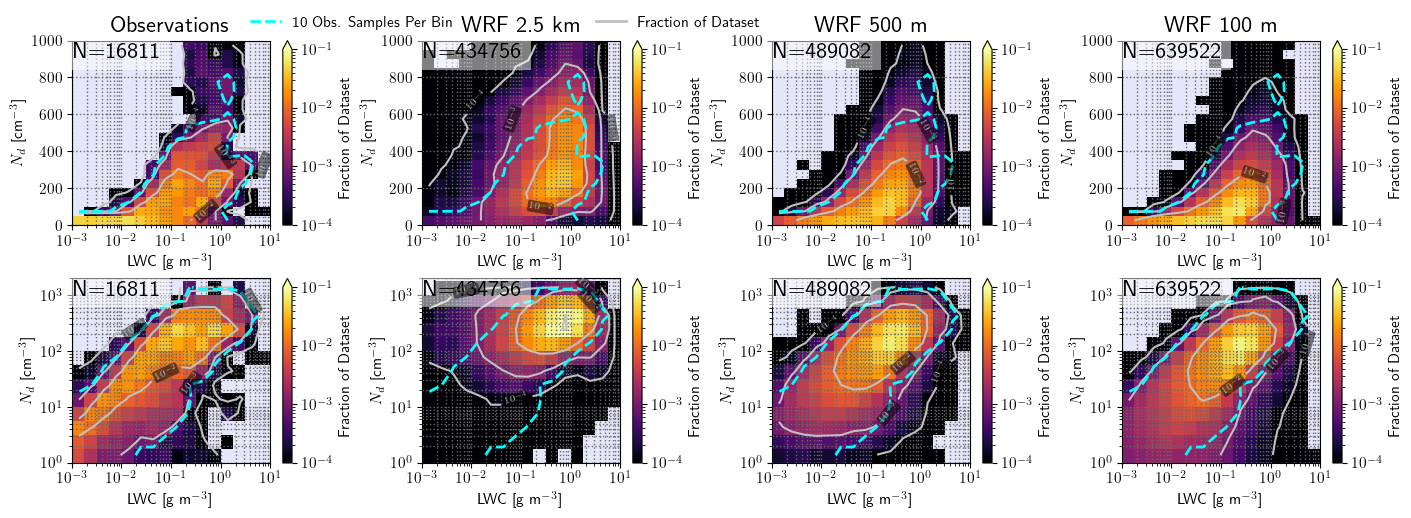

In [32]:
fig = plt.figure(figsize=(14,5),constrained_layout=True)
ax1 = fig.add_subplot(241)
ax2 = fig.add_subplot(242)
ax3 = fig.add_subplot(243)
ax4 = fig.add_subplot(244)
ax5 = fig.add_subplot(245)
ax6 = fig.add_subplot(246)
ax7 = fig.add_subplot(247)
ax8 = fig.add_subplot(248)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]
top_axlist = [ax1,ax2,ax3,ax4]
bot_axlist = [ax5,ax6,ax7,ax8]
Fontsize=11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_ylabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)
    ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    ax.set_xlim(1.e-3,1.e1)
    ax.set_xscale('log')

ax1.set_title("Observations",fontsize=Fontsize*1.5)
ax2.set_title('WRF 2.5 km',fontsize=Fontsize*1.5)
ax3.set_title('WRF 500 m',fontsize=Fontsize*1.5)
ax4.set_title('WRF 100 m',fontsize=Fontsize*1.5)

for ax in top_axlist:
    ax.set_ylim(0,1000)
for ax in bot_axlist:
    ax.set_ylim(1,2.e3)
    ax.set_yscale('log')

cmap = mpl.colormaps.get_cmap('inferno').copy()
vmin=1.e-4
vmax=1.e-1
def fmt(x):
    return f'$10^{{{int(np.log10(x))}}}$'
c_color='silver'
pad=5
c_font = Fontsize*0.6
#=============================================
# Obs
#=============================================

#----------------
# Linear Nd
#----------------
ax=ax1
samp_size = len(obs_dict['total_conc'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_lin, obs_frac_linlog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))
cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))
    
#----------------
# Log Nd
#----------------
ax=ax5
samp_size = len(obs_dict['total_conc'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_log, obs_frac_loglog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))

cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_log,obs_frac_loglog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))
    
#=============================================
# WRF  d2
#=============================================
#----------------
# Linear Nd
#----------------
ax=ax2
samp_size = len(d2_wrf_dict['N'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_lin, d2_wrf_frac_linlog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))
cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_lin,d2_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))
#----------------
# Log Nd
#----------------
ax=ax6
samp_size = len(d2_wrf_dict['N'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_log, d2_wrf_frac_loglog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))

cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_log,d2_wrf_frac_loglog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))

#=============================================
# WRF  d3
#=============================================
#----------------
# Linear Nd
#----------------
ax=ax3
samp_size = len(d3_wrf_dict['N'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_lin, d3_wrf_frac_linlog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))
cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))
#----------------
# Log Nd
#----------------
ax=ax7
samp_size = len(d3_wrf_dict['N'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_log, d3_wrf_frac_loglog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))

cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_log,d3_wrf_frac_loglog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))

#=============================================
# WRF  d4
#=============================================
#----------------
# Linear Nd
#----------------
ax=ax4
samp_size = len(d4_wrf_dict['N'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_lin, d4_wrf_frac_linlog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))
cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_lin,d4_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))
#----------------
# Log Nd
#----------------
ax=ax8
samp_size = len(d4_wrf_dict['N'])
pcm = ax.pcolormesh(lwc_bins, conc_bins_log, d4_wrf_frac_loglog.T, cmap='inferno', norm=mpl.colors.LogNorm(vmin=vmin,vmax=vmax))
ax.text(0.01,0.99,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.5,ha='left',va='top',c='k',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=pad))

cbar = plt.colorbar(pcm,ax=ax,extend='max',pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Fraction of Dataset',fontsize=Fontsize)
cm = ax.contour(lwc_midbins,conc_midbins_log,d4_wrf_frac_loglog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
# Add a semi-transparent background box to each label
for txt in contour_labels:
    txt.set_bbox(dict(facecolor='k', edgecolor='none', alpha=0.5, boxstyle='round,pad=0.2'))




    
back_color = 'lavender'
for ax in axlist:
    ax.set_facecolor(back_color)

# Create a custom legend with just one royal blue line
custom_line = Line2D([0], [0], color=c_color, lw=2)

fig.legend([custom_line], ['Fraction of Dataset'],framealpha=False,bbox_to_anchor=(0.55,1.02),fontsize=Fontsize,bbox_transform=fig.transFigure)

dum_color = 'cyan'

for ax in top_axlist:
    cm_top = ax.contour(lwc_midbins,conc_midbins_lin,obs_hist_linlog.T,levels=[10],colors=dum_color,linewidths=[2],linestyles=['dashed'])
for ax in bot_axlist:
    cm_bot = ax.contour(lwc_midbins,conc_midbins_log,obs_hist_loglog.T,levels=[10],colors=dum_color,linewidths=[2],linestyles=['dashed'])
custom_line = Line2D([0], [0], color=dum_color, lw=2,ls='dashed')
fig.legend([custom_line], ['10 Obs. Samples Per Bin'],framealpha=False,bbox_to_anchor=(0.33,1.02),fontsize=Fontsize,bbox_transform=fig.transFigure)

plt.show()
plt.close()

# Fraction of total mass in sizes > 100 um - Linear Colorscale

In [33]:
tot_mass = obs_dict['cloud_lwc'].copy()
lim_mass = obs_dict['lwc_gt_100um'].copy()
tmp_var = lim_mass/tot_mass

# Obs
lwc_bins = 10.**np.arange(-3.,1.5,0.25) # g/m^3
lwc_midbins = np.array([0.5*(lwc_bins[dd]+lwc_bins[dd+1]) for dd in range(len(lwc_bins)-1)])

conc_bins_lin = np.arange(0,1050,50) # /cm^3
conc_midbins_lin = np.array([0.5*(conc_bins_lin[dd]+conc_bins_lin[dd+1]) for dd in range(len(conc_bins_lin)-1)])

obs_hist_linlog,obs_frac_linlog,obs_pdf_linlog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_lin)
obs_mean_linlog,obs_med_linlog,obs_stddev_linlog = calc_hist2d_filled_special(obs_dict['cloud_lwc'],obs_dict['total_conc'],tmp_var,lwc_bins,conc_bins_lin)

conc_bins_log = 10.**np.arange(0,3.5,0.25)# /cm^3
conc_midbins_log = np.array([0.5*(conc_bins_log[dd]+conc_bins_log[dd+1]) for dd in range(len(conc_bins_log)-1)])

obs_hist_loglog,obs_frac_loglog,obs_pdf_loglog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_log)
obs_mean_loglog,obs_med_loglog,obs_stddev_loglog = calc_hist2d_filled_special(obs_dict['cloud_lwc'],obs_dict['total_conc'],tmp_var,lwc_bins,conc_bins_log)

obs_mean_linlog[obs_mean_linlog == -999.] = np.nan
obs_mean_loglog[obs_mean_loglog == -999.] = np.nan

In [34]:
#======================================
# WRF d2
#======================================
tot_mass = d2_wrf_dict['lwc'].copy()
lim_mass = d2_wrf_dict['q_gt_100um'].copy()*d2_wrf_dict['rho_air'].copy()*1.e3
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# WRF
d2_wrf_hist_linlog,d2_wrf_frac_linlog,d2_wrf_pdf_linlog = calc_hist2d(d2_wrf_dict['lwc'],d2_wrf_dict['N'],lwc_bins,conc_bins_lin)
d2_wrf_mean_linlog,d2_wrf_med_linlog,d2_wrf_stddev_linlog = calc_hist2d_filled_special(d2_wrf_dict['lwc'],d2_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_lin)

d2_wrf_hist_loglog,d2_wrf_frac_loglog,d2_wrf_pdf_loglog = calc_hist2d(d2_wrf_dict['lwc'],d2_wrf_dict['N'],lwc_bins,conc_bins_log)
d2_wrf_mean_loglog,d2_wrf_med_loglog,d2_wrf_stddev_loglog = calc_hist2d_filled_special(d2_wrf_dict['lwc'],d2_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_log)

d2_wrf_mean_linlog[d2_wrf_mean_linlog == -999.] = np.nan
d2_wrf_mean_loglog[d2_wrf_mean_loglog == -999.] = np.nan

0.9999434574930504


In [35]:
#======================================
# WRF d3
#======================================
tot_mass = d3_wrf_dict['lwc'].copy()
lim_mass = d3_wrf_dict['q_gt_100um'].copy()*d3_wrf_dict['rho_air'].copy()*1.e3
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# WRF
d3_wrf_hist_linlog,d3_wrf_frac_linlog,d3_wrf_pdf_linlog = calc_hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['N'],lwc_bins,conc_bins_lin)
d3_wrf_mean_linlog,d3_wrf_med_linlog,d3_wrf_stddev_linlog = calc_hist2d_filled_special(d3_wrf_dict['lwc'],d3_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_lin)

d3_wrf_hist_loglog,d3_wrf_frac_loglog,d3_wrf_pdf_loglog = calc_hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['N'],lwc_bins,conc_bins_log)
d3_wrf_mean_loglog,d3_wrf_med_loglog,d3_wrf_stddev_loglog = calc_hist2d_filled_special(d3_wrf_dict['lwc'],d3_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_log)

d3_wrf_mean_linlog[d3_wrf_mean_linlog == -999.] = np.nan
d3_wrf_mean_loglog[d3_wrf_mean_loglog == -999.] = np.nan

0.9999380569910107


In [36]:
#======================================
# WRF d4
#======================================
tot_mass = d4_wrf_dict['lwc'].copy()
lim_mass = d4_wrf_dict['q_gt_100um'].copy()*d4_wrf_dict['rho_air'].copy()*1.e3
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# WRF
d4_wrf_hist_linlog,d4_wrf_frac_linlog,d4_wrf_pdf_linlog = calc_hist2d(d4_wrf_dict['lwc'],d4_wrf_dict['N'],lwc_bins,conc_bins_lin)
d4_wrf_mean_linlog,d4_wrf_med_linlog,d4_wrf_stddev_linlog = calc_hist2d_filled_special(d4_wrf_dict['lwc'],d4_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_lin)

d4_wrf_hist_loglog,d4_wrf_frac_loglog,d4_wrf_pdf_loglog = calc_hist2d(d4_wrf_dict['lwc'],d4_wrf_dict['N'],lwc_bins,conc_bins_log)
d4_wrf_mean_loglog,d4_wrf_med_loglog,d4_wrf_stddev_loglog = calc_hist2d_filled_special(d4_wrf_dict['lwc'],d4_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_log)

d4_wrf_mean_linlog[d4_wrf_mean_linlog == -999.] = np.nan
d4_wrf_mean_loglog[d4_wrf_mean_loglog == -999.] = np.nan

0.9999431002363173


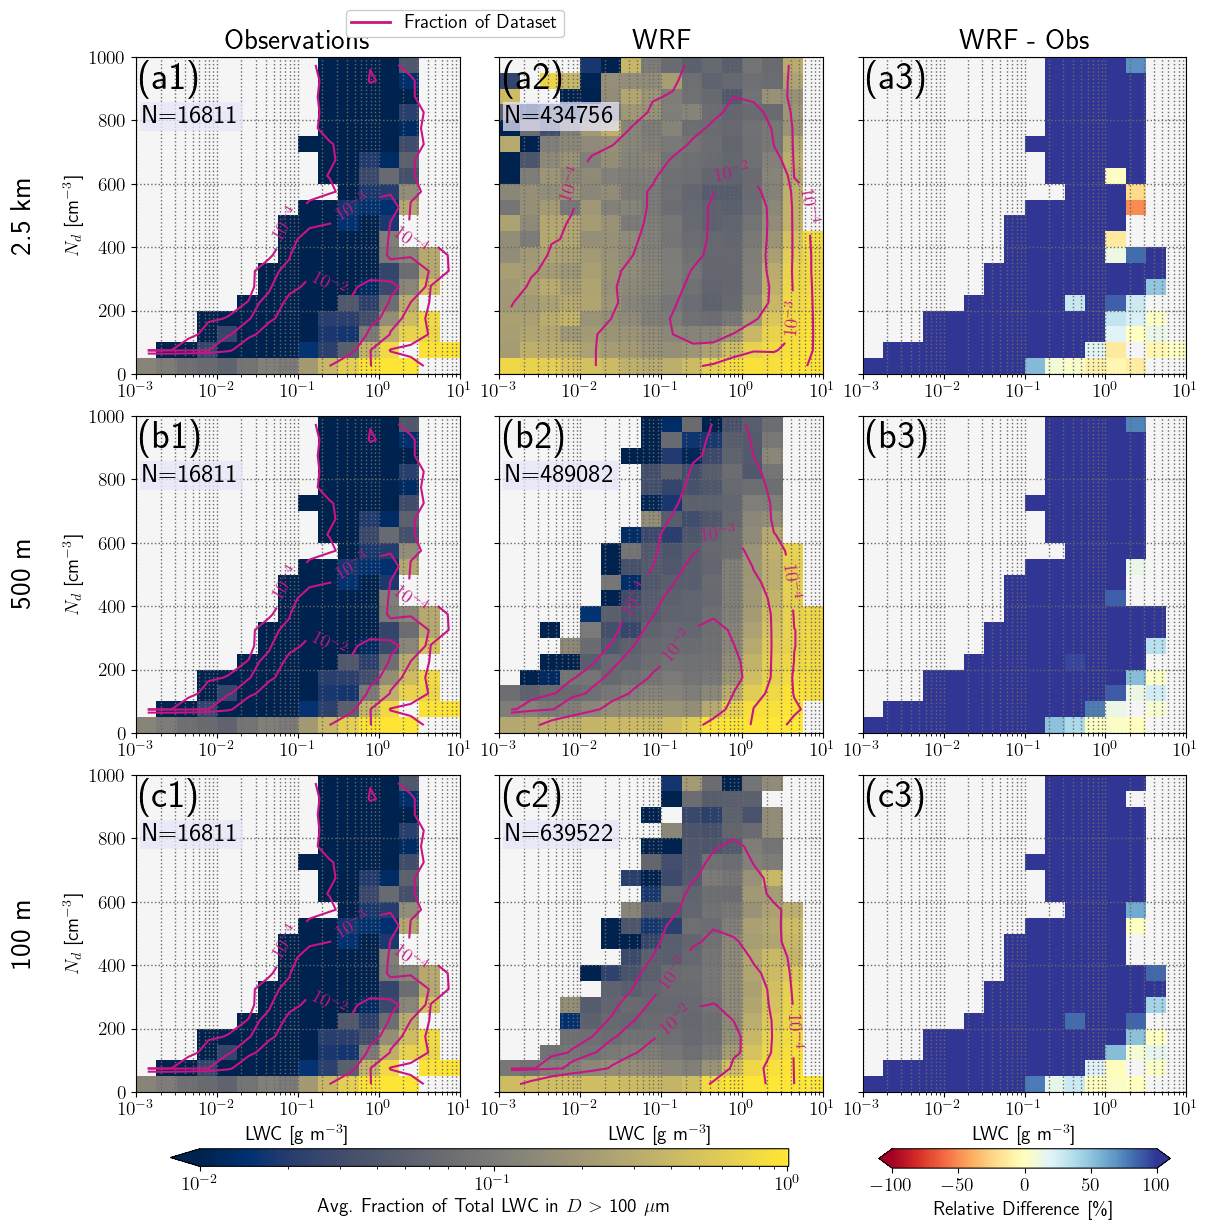

In [37]:
fig = plt.figure(figsize=(12, 12), constrained_layout=True) # Increased height slightly for colorbars
ax1 = fig.add_subplot(331)
ax2 = fig.add_subplot(332)
ax3 = fig.add_subplot(333)
ax4 = fig.add_subplot(334)
ax5 = fig.add_subplot(335)
ax6 = fig.add_subplot(336)
ax7 = fig.add_subplot(337)
ax8 = fig.add_subplot(338)
ax9 = fig.add_subplot(339)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9]
Fontsize=14
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlim(1.e-3,1.e1)
    ax.set_xscale('log')
    

ax1.set_title("Observations",fontsize=Fontsize*1.5)
ax2.set_title('WRF',fontsize=Fontsize*1.5)
ax3.set_title('WRF - Obs',fontsize=Fontsize*1.5)

for ax in axlist:
    ax.set_ylim(0,1000)
axlist_left = [ax1,ax4,ax7]
axlist_mid = [ax2,ax5,ax8]
axlist_right = [ax3,ax6,ax9]
axlist_bot = [ax7,ax8,ax9]
for ax in axlist_mid:
    ax.set_yticklabels([])
for ax in axlist_right:
    ax.set_yticklabels([])

for ax in axlist_left:
    ax.set_ylabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)
for ax in axlist_bot:
    ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    
    

cmap = mpl.colormaps.get_cmap('cividis').copy()

vmin = 1.e-2
vmax = 1.
inc = 0.05
z_bins = np.arange(vmin,vmax+inc,inc) # um
# Custom formatter function to display labels in scientific notation
def fmt(x):
    return f'$10^{{{int(np.log10(x))}}}$'
    
c_color = 'mediumvioletred'
#c_color = 'tomato'
lab = 'Avg. Fraction of Total LWC in $D$ $>$ 100 $\\mu$m' # Removed newline for horizontal label
extend='min'
c_font = 14
dumy=0.85
#=============================================
# Obs - ax1 
#=============================================
ax=ax1
samp_size = len(obs_dict['total_conc'])
dum = obs_mean_linlog.copy() 
dum[dum < vmin] = vmin
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, dum.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))
cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
#=============================================
# Obs - ax4
#=============================================
ax=ax4
samp_size = len(obs_dict['total_conc'])
dum = obs_mean_linlog.copy() 
dum[dum < vmin] = vmin
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, dum.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))
cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
#=============================================
# Obs - ax7
#=============================================
ax=ax7
samp_size = len(obs_dict['total_conc'])
dum = obs_mean_linlog.copy() 
dum[dum < vmin] = vmin
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, dum.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))
cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)


#=============================================
# WRF d2
#=============================================
ax=ax2
samp_size = len(d2_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d2_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d2_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d2
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax3
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d2_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# WRF d3
#=============================================
ax=ax5
samp_size = len(d3_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d3_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d2
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax6
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d3_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# WRF d4
#=============================================
ax=ax8
samp_size = len(d4_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d4_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d4_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d4
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax9
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d4_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)


#=============================================
# ADD NEW HORIZONTAL COLORBARS AT THE BOTTOM
#=============================================

# Shared colorbar for the first two panels
cbar1 = fig.colorbar(pcm1, ax=[ax7, ax8], orientation='horizontal', location='bottom',
                     pad=0.01, extend=extend, shrink=0.9, aspect=35)
cbar1.ax.tick_params(labelsize=Fontsize)
cbar1.set_label(lab, fontsize=Fontsize) # Use set_label for horizontal colorbars

# Separate colorbar for the third panel
cbar3 = fig.colorbar(pcm3, ax=ax9, orientation='horizontal', location='bottom',
                     pad=0.01, extend='both', shrink=0.9, aspect=15)
cbar3.ax.tick_params(labelsize=Fontsize)
cbar3.set_label('Relative Difference [\\%]', fontsize=Fontsize)


labs = ['(a1)','(a2)','(a3)',\
        '(b1)','(b2)','(b3)',\
        '(c1)','(c2)','(c3)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],fontsize=Fontsize*2.,ha='left',va='top',transform=ax.transAxes)


#plt.suptitle('\\underline{\\textbf{Fraction of total LWC in $D$ $>$ 100 $\\mu$m}}', fontsize=Fontsize*1.5, color='navy')
back_color = 'whitesmoke'
for ax in axlist:
    ax.set_facecolor(back_color)
# Create a custom legend
custom_line = Line2D([0], [0], color=c_color, lw=2)
fig.legend([custom_line], ['Fraction of Dataset'],framealpha=True,bbox_to_anchor=(0.475,1.02),fontsize=Fontsize,bbox_transform=fig.transFigure,borderpad=0.25)

labels = ['2.5 km','500 m','100 m']
for i,ax in enumerate(axlist_left):
    ax.text(-0.35,0.5,labels[i],fontsize=Fontsize*1.5,ha='center',va='center',transform=ax.transAxes,rotation=90)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_LWC_Nd_Frac_Joint_Histogram_CLWCthresh.png"
#plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [39]:
fig = plt.figure(figsize=(12, 7), constrained_layout=True) # Increased height slightly for colorbars
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6]
Fontsize=14
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlim(1.e-3,1.e1)
    ax.set_xscale('log')
    



for ax in axlist:
    ax.set_ylim(0,1000)
    
axlist_left = [ax1,ax4]
axlist_mid = [ax2,ax5]
axlist_right = [ax3,ax6]
axlist_bot = [ax4,ax5,ax6]
axlist_top = [ax1,ax2,ax3]
for ax in axlist_mid:
    ax.set_yticklabels([])
for ax in axlist_right:
    ax.set_yticklabels([])

for ax in axlist_left:
    ax.set_ylabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)
for ax in axlist_bot:
    ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)

for ax in axlist_top:
    ax.set_xticklabels([])
    

cmap = mpl.colormaps.get_cmap('cividis').copy()

vmin = 1.e-2
vmax = 1.
inc = 0.05
z_bins = np.arange(vmin,vmax+inc,inc) # um
# Custom formatter function to display labels in scientific notation
def fmt(x):
    return f'$10^{{{int(np.log10(x))}}}$'
    
c_color = 'mediumvioletred'
#c_color = 'tomato'
lab = 'Avg. Fraction of Total LWC in $D$ $>$ 100 $\\mu$m' # Removed newline for horizontal label
extend='min'
c_font = 14
dumy=0.82

#=============================================
# WRF d2
#=============================================
ax=ax1
samp_size = len(d2_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d2_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d2_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d2
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax4
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d2_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# WRF d3
#=============================================
ax=ax2
samp_size = len(d3_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d3_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d2
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax5
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d3_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# WRF d4
#=============================================
ax=ax3
samp_size = len(d4_wrf_dict['N'])
# Use the same colormap and normalization
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, d4_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d4_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d4
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax6
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d4_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm2 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)


#=============================================
# ADD NEW HORIZONTAL COLORBARS AT THE BOTTOM
#=============================================

# Shared colorbar for the first two panels
cbar1 = fig.colorbar(pcm1, ax=ax3, orientation='vertical', location='right',
                     pad=0.01, extend=extend, shrink=1., aspect=15)
cbar1.ax.tick_params(labelsize=Fontsize)
lab = 'Avg. Fraction of Total LWC\nin $D$ $>$ 100 $\\mu$m' # Removed newline for horizontal label
cbar1.set_label(lab, fontsize=Fontsize) # Use set_label for horizontal colorbars

# Separate colorbar for the third panel
cbar2 = fig.colorbar(pcm2, ax=ax6, orientation='vertical', location='right',
                     pad=0.01, extend='both', shrink=1., aspect=15)
cbar2.ax.tick_params(labelsize=Fontsize)
cbar2.set_label('Relative Difference [\\%]', fontsize=Fontsize)


labs = ['(a)','(b)','(c)',\
        '(d)','(e)','(f)']

for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],fontsize=Fontsize*2.,ha='left',va='top',transform=ax.transAxes)


labs = [r'\textbf{2.5 km}',r'\textbf{500 m}',r'\textbf{100 m}']
colors = ['tomato','royalblue','teal']
for i in range(3):
    axlist[i].set_title(labs[i],fontsize=Fontsize*1.5,y=1.01,bbox=dict(facecolor=colors[i], edgecolor='k', alpha=0.5, pad=0.125,boxstyle='round'))
    
ax1.text(-0.35,0.5,r'\textbf{WRF}',ha='center',va='center',rotation=90,transform=ax1.transAxes,fontsize=Fontsize*1.5,\
         bbox=dict(facecolor='wheat', edgecolor='k', alpha=1, pad=0.125,boxstyle='round'))
ax4.text(-0.35,0.5,r'\textbf{WRF - Obs}',ha='center',va='center',rotation=90,transform=ax4.transAxes,fontsize=Fontsize*1.5,\
         bbox=dict(facecolor='wheat', edgecolor='k', alpha=1, pad=0.125,boxstyle='round'))


#plt.suptitle('\\underline{\\textbf{Fraction of total LWC in $D$ $>$ 100 $\\mu$m}}', fontsize=Fontsize*1.5, color='navy')
back_color = 'whitesmoke'
for ax in axlist:
    ax.set_facecolor(back_color)
# Create a custom legend
custom_line = Line2D([0], [0], color=c_color, lw=2)
fig.legend([custom_line], ['Fraction of Dataset'],framealpha=False,bbox_to_anchor=(0.46,1.01),fontsize=Fontsize,bbox_transform=fig.transFigure,borderpad=0.25)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_LWC_Nd_Frac_Joint_Histogram_LASSO_CLWCthresh.png"
plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# Plot composite DSDs & MSDs in different LWC-Nd spaces

In [40]:
obs_lwc = obs_dict['cloud_lwc'].copy() # g/m^3
obs_N = obs_dict['total_conc'].copy() # cm^-3
obs_dNdD = obs_dict['dNdD'].copy() # count/cm^3/um
obs_dMdD = obs_dict['dMdD'].copy() # g/m^3/um
obs_temp = obs_dict['temp'].copy()
obs_alt = obs_dict['alt'].copy()
obs_time = obs_dict['time'].copy()
obs_dZdD = obs_dNdD*1.e6 # m^-3 um^-1
obs_dZdD = obs_dZdD*((obs_diam*1.e-6)**6.) # m^6 m^-3 um^-1
obs_dZdD = obs_dZdD*1.e18 # mm^6 m^-3 um^-1
# obs_diam is in microns
# obs_dD is in microns
# obs_dlogD is in microns
obs_Z = scipy.integrate.trapezoid(obs_dZdD,obs_diam,axis=1)
obs_dBZ = 10.*np.log10(obs_Z)
print(np.nanmax(obs_dBZ),np.nanmin(obs_dBZ))

63.74911129017814 -64.5717049477971


In [41]:
# --- Recommended, Numerically Stable Calculation ---

# Get data in original units
#obs_dNdD_cm = obs_dict['dNdD'].copy() # count/cm^3/um
#obs_diam_um = obs_dict['obs_diam'].copy() # assuming you have this, otherwise calculate bin centers

# 1. Convert everything to base MKS units for the physical calculation
dNdD_mks = obs_dNdD * 1e12  # Units are now: particles / m³ / m
diam_m = obs_diam * 1e-6    # Units are now: m

# 2. Calculate the reflectivity factor distribution, dZ/dD, in MKS units
# (m⁻³ m⁻¹) * m⁶ = m⁵ m⁻³
dZdD_mks = dNdD_mks * (diam_m**6)

# 3. Integrate with respect to diameter in meters to get total Z in MKS units
# (m⁵ / m³) * m  = m⁶ / m³
Z_mks = scipy.integrate.trapezoid(dZdD_mks, diam_m, axis=1)

# 4. NOW, apply the final conversion to conventional radar units (mm⁶ m⁻³)
# 1 m⁶ = (1000 mm)⁶ = 1e18 mm⁶
obs_Z = Z_mks * 1e18

# 5. Convert to dBZ
# Set a floor to avoid log(-inf) for clear air
Z_floor = 1e-8 
obs_Z[obs_Z < Z_floor] = Z_floor
obs_dBZ = 10 * np.log10(obs_Z)

print(np.nanmax(obs_dBZ), np.nanmin(obs_dBZ))

63.74911176089143 -64.57170469290433


In [42]:
if False:
    for ii in range(len(obs_N)):
        print('N:',obs_N[ii])
        print('N_int:',scipy.integrate.trapezoid(obs_dNdD[ii,:],obs_diam))
        print('lwc:',obs_lwc[ii])
        print('lwc_int:',scipy.integrate.trapezoid(obs_dMdD[ii,:],obs_diam))
        
        if ii > 10.:
            break
        print('')

In [43]:
Nd_sep = False
if Nd_sep:
    phase_1_id = np.where( (obs_lwc <= 0.01) & (obs_N < 300.) )[0]
    print(np.shape(phase_1_id))
    phase_2_id = np.where( (obs_lwc > 0.01) & (obs_lwc <= 0.1) & (obs_N < 300.) )[0]
    print(np.shape(phase_2_id))
    phase_3_id = np.where( (obs_lwc > 0.1) & (obs_lwc <= 1.) & (obs_N < 300.) )[0]
    print(np.shape(phase_3_id))
    phase_4_id = np.where( (obs_lwc > 1.) & (obs_N < 300.) )[0]
    print(np.shape(phase_4_id))
    phase_5_id = np.where( (obs_lwc <= 1.) & (obs_N >= 300.) )[0]
    print(np.shape(phase_5_id))
    phase_6_id = np.where( (obs_lwc > 1.) & (obs_N >= 300.) )[0]
    print(np.shape(phase_6_id))
    obs_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id,phase_5_id,phase_6_id]
else:
    phase_1_id = np.where(obs_lwc <= 0.01)[0]
    print(np.shape(phase_1_id))
    phase_2_id = np.where( (obs_lwc > 0.01) & (obs_lwc <= 0.1) )[0]
    print(np.shape(phase_2_id))
    phase_3_id = np.where( (obs_lwc > 0.1) & (obs_lwc <= 1.) )[0]
    print(np.shape(phase_3_id))
    phase_4_id = np.where( obs_lwc > 1. )[0]
    print(np.shape(phase_4_id))
    obs_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id]


(3278,)
(5813,)
(6923,)
(797,)


In [44]:
obs_phase_dict = {}
for ii in range(len(obs_phase_ids)):
    obs_phase_dict['phase_'+str(int(ii+1))] = {}

    # dNdD
    dum = obs_dNdD[obs_phase_ids[ii],:]#/obs_dD # count/cm^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dNdD'] = dum
    dum_mean = np.mean(dum,axis=0) # count/cm^3/um
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dNdD'] = dum_mean

    # dNdlogD
    dum = obs_dNdD[obs_phase_ids[ii],:]*obs_dD/obs_dlogD # count/cm^3
    obs_phase_dict['phase_'+str(int(ii+1))]['dNdlogD'] = dum
    dum_mean = np.mean(dum,axis=0) # count/cm^3/um
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dNdlogD'] = dum_mean

    # dMdD
    dum = obs_dMdD[obs_phase_ids[ii],:]#/obs_dD # g/m^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dMdD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dMdD'] = dum_mean # g/cm^3/um
    
    # dMdlogD
    dum = obs_dMdD[obs_phase_ids[ii],:]*obs_dD/obs_dlogD # g/m^3
    obs_phase_dict['phase_'+str(int(ii+1))]['dMdlogD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dMdlogD'] = dum_mean # g/cm^3/um


    # dZdD
    dum = obs_dZdD[obs_phase_ids[ii],:]#/obs_dD # mm^6/m^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dZdD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dZdD'] = dum_mean  # mm^6/m^3/um
    
    # dZdlogD
    dum = obs_dZdD[obs_phase_ids[ii],:]*obs_dD/obs_dlogD # mm^6/m^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dZdlogD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dZdlogD'] = dum_mean # mm^6/m^3/um
    

In [45]:
rho_w = 1000. # kg/m^3
am = np.pi*rho_w/6. # kg
bm = 3.
mu_r = 0.

In [46]:
wrf_dicts = [d2_wrf_dict,d3_wrf_dict,d4_wrf_dict]
wrf_keys = ['d2','d3','d4']
wrf_top_dict = {}
for ii in range(len(wrf_dicts)):
    key = wrf_keys[ii]
    wrf_top_dict[key] = {}
    wrf_dict = wrf_dicts[ii]
    
    wrf_top_dict[key]['lwc'] = wrf_dict['lwc'].copy() # g/m^3
    wrf_top_dict[key]['N'] = wrf_dict['N'].copy() # cm^-3
    wrf_top_dict[key]['lambda_r'] = wrf_dict['lambda_r'].copy() # m^-1
    wrf_top_dict[key]['lambda_c'] = wrf_dict['lambda_c'].copy() # m^-1
    wrf_top_dict[key]['mu_c'] = wrf_dict['mu_c'].copy() # -
    wrf_top_dict[key]['N_0_r'] = wrf_dict['N_0_r'].copy() # m^-4
    wrf_top_dict[key]['N_0_c'] = wrf_dict['N_0_c'].copy() # m^-4
    wrf_top_dict[key]['qr'] = wrf_dict['qr'].copy() # kg/kg
    wrf_top_dict[key]['qc'] = wrf_dict['qc'].copy() # kg/kg
    wrf_top_dict[key]['Nr'] = wrf_dict['Nr'].copy() # /kg
    wrf_top_dict[key]['Nc'] = wrf_dict['Nc'].copy() # /kg
    wrf_top_dict[key]['rho_air'] = wrf_dict['rho_air'].copy() # kg/m^3

In [47]:
sub_samp = 100000

for ii in range(len(wrf_dicts)):
    key = wrf_keys[ii]
    print(key)
    wrf_lwc = wrf_top_dict[key]['lwc']

    phase_1_id = np.where( wrf_lwc <= 0.01  )[0]
    print(np.shape(phase_1_id))
    if len(phase_1_id) > sub_samp:
        phase_1_id = np.random.choice(phase_1_id, size=sub_samp, replace=False)
    
    phase_2_id = np.where( (wrf_lwc > 0.01) & (wrf_lwc <= 0.1)  )[0]
    print(np.shape(phase_2_id))
    if len(phase_2_id) > sub_samp:
        phase_2_id = np.random.choice(phase_2_id, size=sub_samp, replace=False)
    
    phase_3_id = np.where( (wrf_lwc > 0.1) & (wrf_lwc <= 1.)  )[0]
    print(np.shape(phase_3_id))
    if len(phase_3_id) > sub_samp:
        phase_3_id = np.random.choice(phase_3_id, size=sub_samp, replace=False)
    
    phase_4_id = np.where( wrf_lwc > 1. )[0]
    print(np.shape(phase_4_id))
    
    if len(phase_4_id) > sub_samp:
        phase_4_id = np.random.choice(phase_4_id, size=sub_samp, replace=False)
    
    
    wrf_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id]
    wrf_top_dict[key]['wrf_phase_ids'] = wrf_phase_ids

d2
(3741,)
(31728,)
(294939,)
(104348,)
d3
(25010,)
(139945,)
(309029,)
(15098,)
d4
(44640,)
(198572,)
(380323,)
(15987,)


In [48]:
nD = len(obs_diam)
wrf_phase_dict = {}

for jj in range(len(wrf_dicts)):
    key = wrf_keys[jj]
    wrf_phase_dict[key] = {}
    wrf_phase_ids = wrf_top_dict[key]['wrf_phase_ids']
    wrf_dict = wrf_top_dict[key]
    
    for ii in range(len(wrf_phase_ids)):
        wrf_phase_dict[key]['phase_'+str(int(ii+1))] = {}
        
        phase_id = wrf_phase_ids[ii]
        qr = wrf_dict['qr'][phase_id]
        qc = wrf_dict['qc'][phase_id]
    
        rain_id = np.where(qr > 0.)[0]
        cloud_id = np.where(qc > 0.)[0]
    
        tmp_lambda_r = wrf_dict['lambda_r'][phase_id]
        tmp_lambda_c = wrf_dict['lambda_c'][phase_id]
        tmp_mu_c = wrf_dict['mu_c'][phase_id]
        tmp_N_0_r = wrf_dict['N_0_r'][phase_id]
        tmp_N_0_c = wrf_dict['N_0_c'][phase_id]
    
        D = obs_diam[None, :]*1.e-6  # meters shape (1, nD) for broadcasting
        lambda_r = tmp_lambda_r[:, None]
        lambda_c = tmp_lambda_c[:, None]
        mu_c = tmp_mu_c[:, None]  # cloud mu, not used here yet
        N_0_r = tmp_N_0_r[:, None]
        N_0_c = tmp_N_0_c[:, None]
        dNrdD = N_0_r * (D ** mu_r) * np.exp(-lambda_r * D) # m^-4 
        dMrdD = am * D**bm * dNrdD # g/m^4
        dNcdD = N_0_c * (D ** mu_c) * np.exp(-lambda_c * D) # m^-4 
        dMcdD = am * D**bm * dNcdD # g/m^4 
 
        dNrdD = dNrdD*1.e-6*1.e-6 # cm^-3 um^-1
        dNcdD = dNcdD*1.e-6*1.e-6 # cm^-3 um^-1
        dMrdD = dMrdD*1.e-6*1.e3 # g m^-3 um^-1
        dMcdD = dMcdD*1.e-6*1.e3 # g m^-3 um^-1
    
        dNrdD[np.isnan(dNrdD)] = 0.
        dNcdD[np.isnan(dNcdD)] = 0.
        dMrdD[np.isnan(dMrdD)] = 0.
        dMcdD[np.isnan(dMcdD)] = 0.
        dNdD = dNrdD + dNcdD
        dMdD = dMrdD + dMcdD
        dZdD = (dNdD*1.e6)*1.e18*(obs_diam*1.e-6)**6. # mm^6 m^-3 um^-1
        
    
        dNdlogD = dNdD*obs_dD/obs_dlogD # cm^-3
        dMdlogD = dMdD*obs_dD/obs_dlogD # g m^-3
        dZdlogD = dZdD*obs_dD/obs_dlogD # mm^6 m^-3
        
        
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['dNdD'] = dNdD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['dMdD'] = dMdD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['dZdD'] = dZdD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['dNdlogD'] = dNdlogD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['dMdlogD'] = dMdlogD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['dZdlogD'] = dZdlogD
    
        mean_dNdD = np.mean(dNdD,axis=0)
        mean_dNdD[mean_dNdD == 0.] = np.nan
        
        mean_dMdD = np.mean(dMdD,axis=0)
        mean_dMdD[mean_dMdD == 0.] = np.nan
    
        mean_dZdD = np.mean(dZdD,axis=0)
        mean_dZdD[mean_dZdD == 0.] = np.nan
        
        mean_dNdlogD = np.mean(dNdlogD,axis=0)
        mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
        
        mean_dMdlogD = np.mean(dMdlogD,axis=0)
        mean_dMdlogD[mean_dMdlogD == 0.] = np.nan
    
        mean_dZdlogD = np.mean(dZdlogD,axis=0)
        mean_dZdlogD[mean_dZdlogD == 0.] = np.nan
        
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['mean_dNdD'] = mean_dNdD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['mean_dMdD'] = mean_dMdD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['mean_dZdD'] = mean_dZdD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['mean_dNdlogD'] = mean_dNdlogD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['mean_dMdlogD'] = mean_dMdlogD
        wrf_phase_dict[key]['phase_'+str(int(ii+1))]['mean_dZdlogD'] = mean_dZdlogD
    print('done')

done
done
done


In [49]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx], idx
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'
from matplotlib.patches import Rectangle # You need to import this
from matplotlib.patheffects import withStroke # For text outlines

In [50]:
# --- Helper Function to process and plot data for one source (Obs or WRF) ---
def process_and_plot(axes, data_dict, diam_bins, line_color, marker_color):
    """
    Calculates statistics, plots distributions and mean/median diameters.
    Returns integrated values for text annotation.
    """
    axa, axb, axc = axes

    # Extract data for clarity
    dNdlogD = data_dict['mean_dNdlogD']
    dMdlogD = data_dict['mean_dMdlogD']
    dZdlogD = data_dict['mean_dZdlogD']
    dNdD = data_dict['mean_dNdD'].copy()
    dNdD[np.isnan(dNdD)] = 0.0
    dMdD = data_dict['mean_dMdD'].copy()
    dMdD[np.isnan(dMdD)] = 0.0
    dZdD = data_dict['mean_dZdD'].copy()
    dZdD[np.isnan(dZdD)] = 0.0
    
    # Plot distributions
    axa.step(diam_bins, dNdlogD, lw=2, c=line_color, where='mid')
    axb.step(diam_bins, dMdlogD, lw=2, c=line_color, where='mid')
    axc.step(diam_bins, dZdlogD, lw=2, c=line_color, where='mid')

    # --- Calculate and Plot Diameters ---
    # Number-weighted mean diameter (Dn)
    num_wgt_mean_diam = scipy.integrate.trapezoid(dNdD * diam_bins, diam_bins) / scipy.integrate.trapezoid(dNdD, diam_bins)
    #print(num_wgt_mean_diam)
    _, nearest_id = find_nearest(diam_bins, num_wgt_mean_diam)
    axa.plot(num_wgt_mean_diam, dNdlogD[nearest_id], 'X', ms=12, c=marker_color, mew=1, zorder=1000,mec='k')

    # Mass-weighted mean diameter (Dm)
    mass_wgt_mean_diam = scipy.integrate.trapezoid(dMdD * diam_bins, diam_bins) / scipy.integrate.trapezoid(dMdD, diam_bins)
    #print(mass_wgt_mean_diam)
    _, nearest_id = find_nearest(diam_bins, mass_wgt_mean_diam)
    axb.plot(mass_wgt_mean_diam, dMdlogD[nearest_id], '^', ms=12, c=marker_color, mew=1, zorder=1000,mec='k')

    # Median mass diameter (MMD)
    cum_mass = scipy.integrate.cumulative_trapezoid(dMdD, diam_bins, initial=0)
    cum_mass /= cum_mass[-1]
    median_idx = np.searchsorted(cum_mass, 0.5)
    median_mass_diam = diam_bins[median_idx]
    #print(median_mass_diam)
    axb.plot(median_mass_diam, dMdlogD[median_idx], 's', ms=9, c=marker_color, mew=1, zorder=1000,mec='k')
    
    # --- Calculate Integrated Values ---
    int_num = np.trapz(np.nan_to_num(dNdD), diam_bins)
    int_mass = np.trapz(np.nan_to_num(dMdD), diam_bins)
    int_ref = np.trapz(np.nan_to_num(dZdD), diam_bins)
    int_dbz = 10. * np.log10(int_ref) if int_ref > 0 else -np.inf

    return int_num, int_mass, int_dbz

In [51]:
print(wrf_phase_dict.keys())
print(wrf_phase_dict['d2'].keys())
print(wrf_phase_dict['d2']['phase_1'].keys())

dict_keys(['d2', 'd3', 'd4'])
dict_keys(['phase_1', 'phase_2', 'phase_3', 'phase_4'])
dict_keys(['dNdD', 'dMdD', 'dZdD', 'dNdlogD', 'dMdlogD', 'dZdlogD', 'mean_dNdD', 'mean_dMdD', 'mean_dZdD', 'mean_dNdlogD', 'mean_dMdlogD', 'mean_dZdlogD'])


In [53]:
# --- Main Plotting Script ---
Fontsize = 16

# 1. Use plt.subplots to create the figure and all axes at once
fig, axs = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True)

# 2. Configure all axes in a single loop
for ax in axs.flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1.e4)
    ax.set_xticks([1,10,1.e2,1.e3,1.e4])

# Set shared labels
for ax in axs[-1,:]:
    ax.set_xlabel('Diameter [$\\mu$m]', fontsize=Fontsize)

# Set y-axis labels for the first column
ylabels = ['dN/dlogD [cm$^{-3}$]', 'dM/dlogD [g m$^{-3}$]', 'dZ/dlogD [mm$^{6}$ m$^{-3}$]']
for i, label in enumerate(ylabels):
    axs[i, 0].set_ylabel(label, fontsize=Fontsize)

# Set y-limits per row
ylims = [(1.e-10, 1.e6), (1.e-8, 1.e2), (1.e-10,1.e6)] # None for the third row, or set specific limits
for i, ylim in enumerate(ylims):
    if ylim:
        for ax in axs[i, :]:
            ax.set_ylim(ylim)

# 3. Use data-driven configuration for titles and formatting
titles = [
    '\\textbf{10$^{-3}$ \\textless \ LWC $\\leq$ 10$^{-2}$ g m$^{-3}$}',
    '\\textbf{10$^{-2}$ \\textless \ LWC $\\leq$ 10$^{-1}$ g m$^{-3}$}',
    '\\textbf{10$^{-1}$ \\textless \ LWC $\\leq$ 1 g m$^{-3}$}',
    '\\textbf{LWC \\textgreater \ 1 g m$^{-3}$}',
]
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
title_colors = ['k','k','k','k']
float_precisions = [3, 3, 2, 2] # Number of decimal places for LWC text

# 4. Main loop using the helper function
for i, key in enumerate(obs_phase_dict.keys()):
    
    current_axes = axs[:, i] # Get the column of axes for this iteration
    axa, axb, axc = current_axes

    # Process and plot observations
    obs_num, obs_mass, obs_dbz = process_and_plot(
        current_axes, obs_phase_dict[key], obs_diam, line_color='k', marker_color='dimgrey'
    )
    obs_samp_size = len(obs_phase_dict[key]['dNdD'][:, 0])

    colors = ['tomato','royalblue','teal']
    for j,key2 in enumerate(wrf_phase_dict.keys()):
        # Process and plot WRF model data
        wrf_num, wrf_mass, wrf_dbz = process_and_plot(
            current_axes, wrf_phase_dict[key2][key], obs_diam, line_color=colors[j], marker_color=colors[j]
        )

        # Sample sizes
        fac=0.8
        fac2=0.65

        #-------------------------------------    
        # Sample Sizes
        #-------------------------------------
        wrf_samp_size = len(wrf_phase_dict[key2][key]['dNdD'][:, 0])
        x_corner,y_corner, box_width, box_height = 0.45, 0.65, 0.58, 0.34  
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='lavender',alpha=0.99,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        axa.add_patch(rect)
        if j == 0.:
            axa.text(0.99, 0.98, r'$\mathbf{N_{\mathrm{obs}}=' + str(obs_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes,zorder=11)
        axa.text(0.99, 0.98 - (j+1)*0.08, r'$\mathbf{N_{\mathrm{WRF}}=' + str(wrf_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes, c=colors[j],zorder=11)

        #-------------------------------------    
        # Integrated Number
        #-------------------------------------
        x_corner,y_corner, box_width, box_height = 0.01, 0.005, 0.46, 0.31
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        axa.add_patch(rect)
        if j == 0.:
            axa.text(0.01, 0.29, f'$\\mathit{{N_d}} = \\mathbf{{{int(obs_num)}}} \\ \\mathrm{{\\mathbf{{cm}}^{{-3}}}}$', fontsize=Fontsize*fac2, ha='left', va='top', transform=axa.transAxes,zorder=11)
        axa.text(0.01, 0.29 - (j+1)*0.07, f'$\\mathit{{N_d}} = \\mathbf{{{int(wrf_num)}}} \\ \\mathrm{{\\mathbf{{cm}}^{{-3}}}}$', fontsize=Fontsize*fac2, ha='left', va='top', transform=axa.transAxes, c=colors[j],zorder=11)

        #-------------------------------------    
        # Integrated Mass (LWC)
        #-------------------------------------
        precision = float_precisions[i]
        obs_str = f"{obs_mass:.{precision}f}"
        wrf_str = f"{wrf_mass:.{precision}f}"
        # Use different y-positions for columns 2 and 3
        y_pos1 = 0.98 if i in [0, 1] else 0.28
        if i in [0, 1]:
            x_corner,y_corner, box_width, box_height = 0.4, 0.69, 0.6, 0.3
        else:
            x_corner,y_corner, box_width, box_height = 0.42, 0.005, 0.58, 0.28
            
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axb.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        axb.add_patch(rect)
        if j == 0.:
            axb.text(0.99, y_pos1, f'$\\mathbf{{LWC={obs_str}\\ g\\ m^{{-3}}}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axb.transAxes,zorder=11)
        axb.text(0.99, y_pos1 - (j+1)*0.07, f'$\\mathbf{{LWC={wrf_str}\\ g\\ m^{{-3}}}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axb.transAxes, c=colors[j],zorder=11)


        #-------------------------------------
        # Integrated Reflectivity (Ze)
        #-------------------------------------
        x_corner,y_corner, box_width, box_height = 0.6, 0.005, 0.4, 0.3
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axc.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        axc.add_patch(rect)
        if j == 0.:
            axc.text(0.99, 0.28, f'$\\mathbf{{\\mathit{{Z_e}} = {int(obs_dbz)}\\ dBZ}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axc.transAxes,zorder=11)
        axc.text(0.99, 0.28 - (j+1)*0.07, f'$\\mathbf{{\\mathit{{Z_e}} = {int(wrf_dbz)}\\ dBZ}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axc.transAxes, c=colors[j],zorder=11)
        
    # Set titles for the top row
    axs[0, i].set_title(titles[i], fontsize=Fontsize*0.9, c='k')
    

# --- Legends (your original code for this was already good) ---
def create_styled_legend(fig, handles, **kwargs):
    legend = fig.legend(handles=handles, **kwargs)
    legend.get_frame().set_boxstyle('square')
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')
    return legend

# Legend 1: Lines
line_legend_handles = [
    Line2D([0], [0], color='k', lw=2, label='Observations'),
    Line2D([0], [0], color='tomato', lw=2, label='WRF 2.5 km'),
    Line2D([0], [0], color='royalblue', lw=2, label='WRF 500 m'),
    Line2D([0], [0], color='teal', lw=2, label='WRF 100 m'),
]
create_styled_legend(fig, line_legend_handles, loc='lower center', bbox_to_anchor=(0.16, -0.14), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)

# Legend 2: Markers
marker_legend_handles = [
    Line2D([0], [0], ls='None', marker='X', c='k', label='Number-weighted Mean Diameter', ms=10, mew=1),
    Line2D([0], [0], ls='None', marker='^', c='k', label='Mass-weighted Mean Diameter', ms=12, mew=1),
    Line2D([0], [0], ls='None', marker='s', c='k', label='Median Mass Diameter', ms=9, mew=1)
]
create_styled_legend(fig, marker_legend_handles, loc='lower center', bbox_to_anchor=(0.47, -0.11), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)


dum_list = ['a','b','c']
for j in range(3):
    tmp_axs = axs[j,:]
    for i,ax in enumerate(tmp_axs):
        #ax.text(0.02,0.98,r'\textbf{('+dum_list[j]+str(int(i+1))+')}',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')
        ax.text(0.02,0.98,r'('+dum_list[j]+str(int(i+1))+')',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')


for i in range(4):
    ax = axs[0,i]
    ax.set_yticks([1.e-8,1.e-4,1.e0,1.e4])
    
for i in range(4):
    ax = axs[1,i]
    ax.set_yticks([1.e-6,1.e-4,1.e-2,1.e0])

for i in range(3):
    for j in range(1,4):
        axs[i,j].set_yticklabels([])

    
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_Aircraft_SDs_LASSO_CLWCthresh.png"
plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


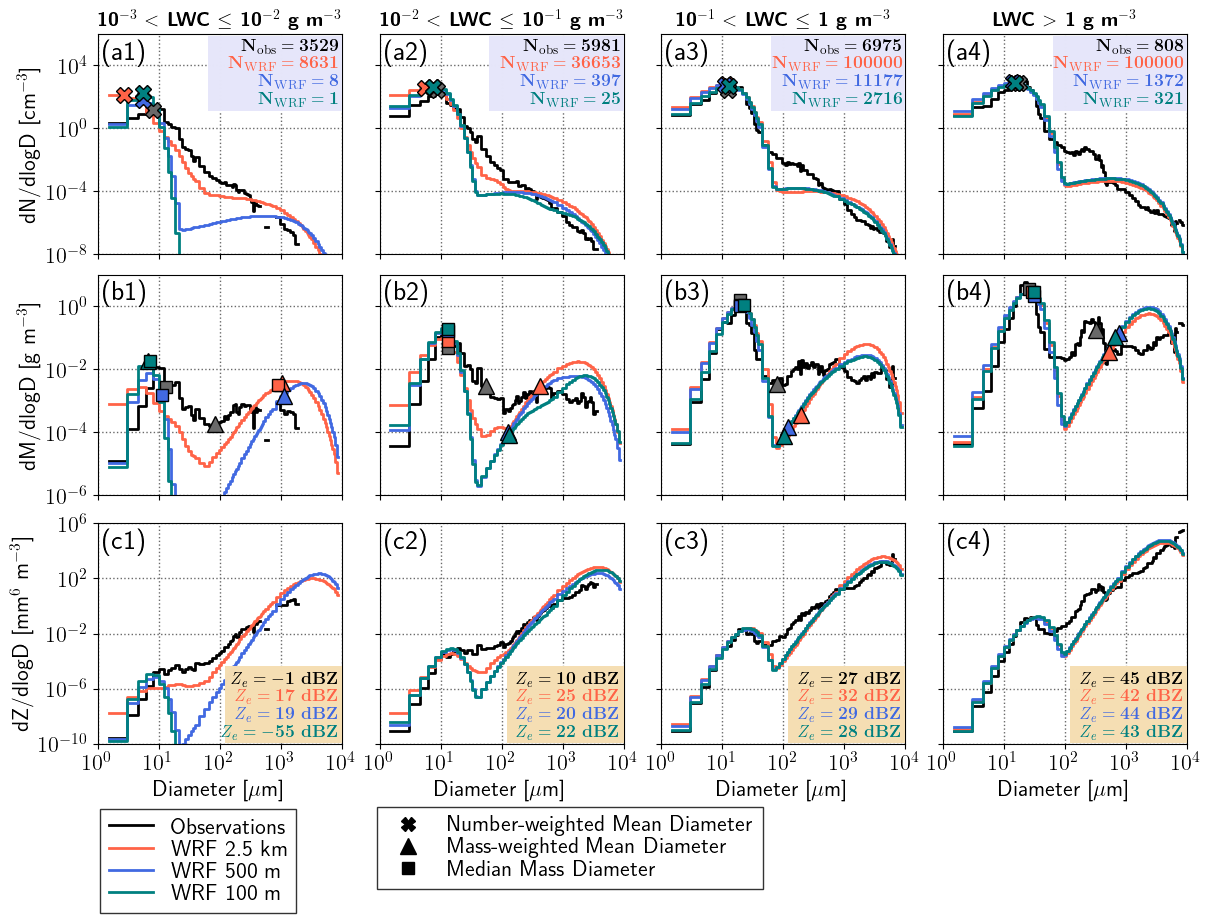

In [85]:
# --- Main Plotting Script ---
Fontsize = 16

# 1. Use plt.subplots to create the figure and all axes at once
fig, axs = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True)

# 2. Configure all axes in a single loop
for ax in axs.flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1.e4)
    ax.set_xticks([1,10,1.e2,1.e3,1.e4])

# Set shared labels
for ax in axs[-1,:]:
    ax.set_xlabel('Diameter [$\\mu$m]', fontsize=Fontsize)

# Set y-axis labels for the first column
ylabels = ['dN/dlogD [cm$^{-3}$]', 'dM/dlogD [g m$^{-3}$]', 'dZ/dlogD [mm$^{6}$ m$^{-3}$]']
for i, label in enumerate(ylabels):
    axs[i, 0].set_ylabel(label, fontsize=Fontsize)

# Set y-limits per row
ylims = [(1.e-8, 1.e6), (1.e-6, 1.e1), (1.e-10,1.e6)] # None for the third row, or set specific limits
for i, ylim in enumerate(ylims):
    if ylim:
        for ax in axs[i, :]:
            ax.set_ylim(ylim)

# 3. Use data-driven configuration for titles and formatting
titles = [
    '\\textbf{10$^{-3}$ \\textless \ LWC $\\leq$ 10$^{-2}$ g m$^{-3}$}',
    '\\textbf{10$^{-2}$ \\textless \ LWC $\\leq$ 10$^{-1}$ g m$^{-3}$}',
    '\\textbf{10$^{-1}$ \\textless \ LWC $\\leq$ 1 g m$^{-3}$}',
    '\\textbf{LWC \\textgreater \ 1 g m$^{-3}$}',
]
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
title_colors = ['k','k','k','k']
float_precisions = [3, 3, 2, 2] # Number of decimal places for LWC text

# 4. Main loop using the helper function
for i, key in enumerate(obs_phase_dict.keys()):
    
    current_axes = axs[:, i] # Get the column of axes for this iteration
    axa, axb, axc = current_axes

    # Process and plot observations
    obs_num, obs_mass, obs_dbz = process_and_plot(
        current_axes, obs_phase_dict[key], obs_diam, line_color='k', marker_color='dimgrey'
    )
    obs_samp_size = len(obs_phase_dict[key]['dNdD'][:, 0])

    colors = ['tomato','royalblue','teal']
    for j,key2 in enumerate(wrf_phase_dict.keys()):
        # Process and plot WRF model data
        wrf_num, wrf_mass, wrf_dbz = process_and_plot(
            current_axes, wrf_phase_dict[key2][key], obs_diam, line_color=colors[j], marker_color=colors[j]
        )

        # Sample sizes
        fac=0.8
        fac2=0.7

        #-------------------------------------    
        # Sample Sizes
        #-------------------------------------
        wrf_samp_size = len(wrf_phase_dict[key2][key]['dNdD'][:, 0])
        x_corner,y_corner, box_width, box_height = 0.45, 0.65, 0.58, 0.34  
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='lavender',alpha=0.99,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        axa.add_patch(rect)
        if j == 0.:
            axa.text(0.99, 0.98, r'$\mathbf{N_{\mathrm{obs}}=' + str(obs_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes,zorder=11)
        axa.text(0.99, 0.98 - (j+1)*0.08, r'$\mathbf{N_{\mathrm{WRF}}=' + str(wrf_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes, c=colors[j],zorder=11)

        #-------------------------------------    
        # Integrated Number
        #-------------------------------------
        x_corner,y_corner, box_width, box_height = 0.01, 0.005, 0.55, 0.22 
        #rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        #axa.add_patch(rect)
        #if j == 0.:
        #    axa.text(0.01, 0.3, f'$\\mathit{{N_d}} = \\mathbf{{{int(obs_num)}}} \\ \\mathrm{{\\mathbf{{cm}}^{{-3}}}}$', fontsize=Fontsize*fac2, ha='left', va='top', transform=axa.transAxes,zorder=11)
        #axa.text(0.01, 0.3 - (j+1)*0.08, f'$\\mathit{{N_d}} = \\mathbf{{{int(wrf_num)}}} \\ \\mathrm{{\\mathbf{{cm}}^{{-3}}}}$', fontsize=Fontsize*fac2, ha='left', va='top', transform=axa.transAxes, c=colors[j],zorder=11)

        #-------------------------------------    
        # Integrated Mass (LWC)
        #-------------------------------------
        precision = float_precisions[i]
        obs_str = f"{obs_mass:.{precision}f}"
        wrf_str = f"{wrf_mass:.{precision}f}"
        # Use different y-positions for columns 2 and 3
        y_pos1 = 0.98 if i in [0, 1] else 0.32
        if i in [0,1]:
            x_corner,y_corner, box_width, box_height = 0.29, 0.8, 0.71, 0.19  
        else:
            x_corner,y_corner, box_width, box_height = 0.33, 0.005, 0.67, 0.22 
            
        #rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axb.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        #axb.add_patch(rect)
        #if j == 0.:
        #    axb.text(0.99, y_pos1, f'$\\mathbf{{LWC={obs_str}\\ g\\ m^{{-3}}}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axb.transAxes,zorder=11)
        #axb.text(0.99, y_pos1 - (j+1)*0.08, f'$\\mathbf{{LWC={wrf_str}\\ g\\ m^{{-3}}}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axb.transAxes, c=colors[j],zorder=11)


        #-------------------------------------
        # Integrated Reflectivity (Ze)
        #-------------------------------------
        x_corner,y_corner, box_width, box_height = 0.52, 0.005, 0.48, 0.35 
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axc.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        axc.add_patch(rect)
        if j == 0.:
            axc.text(0.99, 0.33, f'$\\mathbf{{\\mathit{{Z_e}} = {int(obs_dbz)}\\ dBZ}}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axc.transAxes,zorder=11)
        axc.text(0.99, 0.33 - (j+1)*0.08, f'$\\mathbf{{\\mathit{{Z_e}} = {int(wrf_dbz)}\\ dBZ}}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axc.transAxes, c=colors[j],zorder=11)
        
    # Set titles for the top row
    axs[0, i].set_title(titles[i], fontsize=Fontsize*0.9, c='k')
    

# --- Legends (your original code for this was already good) ---
def create_styled_legend(fig, handles, **kwargs):
    legend = fig.legend(handles=handles, **kwargs)
    legend.get_frame().set_boxstyle('square')
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')
    return legend

# Legend 1: Lines
line_legend_handles = [
    Line2D([0], [0], color='k', lw=2, label='Observations'),
    Line2D([0], [0], color='tomato', lw=2, label='WRF 2.5 km'),
    Line2D([0], [0], color='royalblue', lw=2, label='WRF 500 m'),
    Line2D([0], [0], color='teal', lw=2, label='WRF 100 m'),
]
create_styled_legend(fig, line_legend_handles, loc='lower center', bbox_to_anchor=(0.16, -0.14), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)

# Legend 2: Markers
marker_legend_handles = [
    Line2D([0], [0], ls='None', marker='X', c='k', label='Number-weighted Mean Diameter', ms=10, mew=1),
    Line2D([0], [0], ls='None', marker='^', c='k', label='Mass-weighted Mean Diameter', ms=12, mew=1),
    Line2D([0], [0], ls='None', marker='s', c='k', label='Median Mass Diameter', ms=9, mew=1)
]
create_styled_legend(fig, marker_legend_handles, loc='lower center', bbox_to_anchor=(0.47, -0.11), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)


dum_list = ['a','b','c']
for j in range(3):
    tmp_axs = axs[j,:]
    for i,ax in enumerate(tmp_axs):
        #ax.text(0.02,0.98,r'\textbf{('+dum_list[j]+str(int(i+1))+')}',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')
        ax.text(0.02,0.98,r'('+dum_list[j]+str(int(i+1))+')',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')

for i in range(3):
    for j in range(1,4):
        axs[i,j].set_yticklabels([])
    
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_Aircraft_SDs_LASSO.png"
#plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()